In [116]:
import pandas as pd

Data = pd.read_csv(r"Datos\Poisson_Train.csv")
X = Data[["x_1", "x_2", "x_3", "x_4"]].values
y = Data["y"].values

In [117]:
# Verificamos si hay NaNs en el DataFrame
print("Cantidad de NaNs en cada columna:")
print(Data.isna().sum())
# Verificamos la proporción de NaNs en cada columna
print("Proporción de NaNs en cada columna:")
print(Data.isna().mean())

Cantidad de NaNs en cada columna:
x_1    0
x_2    0
x_3    0
x_4    0
y      0
dtype: int64
Proporción de NaNs en cada columna:
x_1    0.0
x_2    0.0
x_3    0.0
x_4    0.0
y      0.0
dtype: float64


Media: 3525432.07, Mediana: 1514822.00, Desviación estándar: 5195813.90


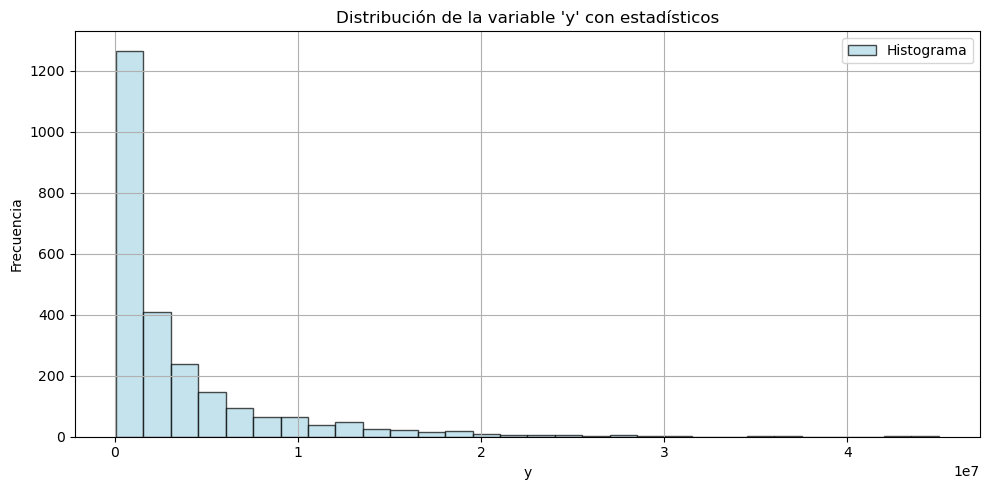

In [118]:
import numpy as np
import matplotlib.pyplot as plt
# Estadísticos
media = np.mean(y)
mediana = np.median(y)
std_dev = np.std(y)
# Estadísticos
print(f"Media: {media:.2f}, Mediana: {mediana:.2f}, Desviación estándar: {std_dev:.2f}")

# Histograma con líneas
plt.figure(figsize=(10, 5))
plt.hist(y, bins=30, color='lightblue', edgecolor='black', alpha=0.7, label="Histograma")

# Líneas estadísticas
#plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f"Media: {media:,.0f}")
#plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f"Mediana: {mediana:,.0f}")
#plt.axvline(media + std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media + 1σ")
#plt.axvline(media - std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media - 1σ")

# Estética
plt.title("Distribución de la variable 'y' con estadísticos")
plt.xlabel("y")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Nuestro dataset tiene pinta de seguir una distribución de Poisson con lambda 1

In [119]:
"""implementación una regresión de Poisson"""
class PoissonRegression:
    def __init__(self, lr=0.001, n_iter=10000, tol=1e-6):
        self.lr = lr 
        self.n_iter = n_iter
        self.tol = tol 
        self.theta = None  

    def grad(self, X, y, theta):
        eta = X.dot(theta)
        mu = np.exp(eta)
        # Log-likelihood negativo (para minimizar)
        loss = -np.sum(y * eta - mu)
        # Gradiente
        grad = -np.sum((y - mu)[:, None] * X, axis=0)
        return loss, grad

    def fit(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        n, m = X.shape
        theta = np.zeros(m)
        prev_loss = np.inf
        for iteration in range(self.n_iter):
            loss, grad = self.grad(X, y, theta)
            theta = theta - self.lr * grad
            if np.abs(prev_loss - loss) < self.tol:
                print(f"Convergencia alcanzada en la iteración {iteration}")
                break
            prev_loss = loss
        self.theta = theta

    def predict(self, X):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        if self.theta is None:
            raise ValueError("El modelo no ha sido ajustado. Llama a fit() primero.")
        eta = X.dot(self.theta)
        mu = np.exp(eta)
        return mu

    def loss(self, X, y):
        X = np.hstack((np.ones((X.shape[0], 1)), X))
        eta = X.dot(self.theta)
        mu = np.exp(eta)
        # Log-likelihood negativo
        res = -np.sum(y * eta - mu)
        return res

In [120]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_absolute_error, r2_score

scaler = StandardScaler() # optamos por normalizar los datos porque tenemos overflow numérico
X_scaled = scaler.fit_transform(X)

model = PoissonRegression(lr=1e-6, n_iter=10000, tol=1e-8)
model.fit(X_scaled, y)  
y_pred = model.predict(X_scaled) 

reg = PoissonRegressor(alpha=1.0, max_iter=300)
reg.fit(X_scaled, y)
y_pred_sklearn = reg.predict(X_scaled)

print("MAE (nuestro):", mean_absolute_error(y, y_pred))
print("MAE (sklearn):", mean_absolute_error(y, y_pred_sklearn))
print("R2 (nuestro):", r2_score(y, y_pred))
print("R2 (sklearn):", r2_score(y, y_pred_sklearn))
print("Coef nuestro:", model.theta)
print("Coef sklearn:", np.append(reg.intercept_, reg.coef_))

C:\Users\Juan\AppData\Local\Temp\ipykernel_22328\450416277.py:11: RuntimeWarning: overflow encountered in exp
  mu = np.exp(eta)
c:\Users\Juan\anaconda3\envs\multivariado\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


ValueError: Input contains NaN.

Estamos teniendo nans en las predicciones, por lo que hay un overflow numerico de np.exp 
si vemos los valores de y son muy grandes, para probar escalamos por una constante y dividiendo y multiplicando en la medición.

In [121]:
model = PoissonRegression(lr=1e-6, n_iter=10000, tol=1e-8)
model.fit(X_scaled, y/10000)  # Normalizamos y para evitar overflow
y_pred = model.predict(X_scaled) * 10000  # Desnormalizamos las predicciones

reg = PoissonRegressor(alpha=1.0, max_iter=300)
reg.fit(X_scaled, y)
y_pred_sklearn = reg.predict(X_scaled)

print("MAE (nuestro):", mean_absolute_error(y, y_pred))
print("MAE (sklearn):", mean_absolute_error(y, y_pred_sklearn))
print("R2 (nuestro):", r2_score(y, y_pred))
print("R2 (sklearn):", r2_score(y, y_pred_sklearn))
print("Coef nuestro:", model.theta)
print("Coef sklearn:", np.append(reg.intercept_, reg.coef_))

MAE (nuestro): 965532.9440610842
MAE (sklearn): 1212.263408189421
R2 (nuestro): 0.8250968821665671
R2 (sklearn): 0.9999998752004712
Coef nuestro: [ 5.06765696  0.09354896 -0.09354896  0.6429057   1.4001234 ]
Coef sklearn: [14.16992151  0.11307363 -0.11307363  0.58489964  1.29178498]


Teniendo en cuenta esto. Luego de varios intentos fuimos reduciendo el learning rate, sin escalar y, logramos entrenar el modelo sin errores logrando resultados muy cercanos a scikitlearn.

In [122]:

model = PoissonRegression(lr=1e-11, n_iter=10000, tol=1e-8) # Ajustamos la tasa de aprendizaje
model.fit(X_scaled, y)  
y_pred = model.predict(X_scaled) 

reg = PoissonRegressor(alpha=1.0, max_iter=300)
reg.fit(X_scaled, y)
y_pred_sklearn = reg.predict(X_scaled)

print("MAE (nuestro):", mean_absolute_error(y, y_pred))
print("MAE (sklearn):", mean_absolute_error(y, y_pred_sklearn))
print("R2 (nuestro):", r2_score(y, y_pred))
print("R2 (sklearn):", r2_score(y, y_pred_sklearn))
print("Coef nuestro:", model.theta)
print("Coef sklearn:", np.append(reg.intercept_, reg.coef_))

Convergencia alcanzada en la iteración 1306
MAE (nuestro): 1212.3220143703325
MAE (sklearn): 1212.263408189421
R2 (nuestro): 0.9999998751698943
R2 (sklearn): 0.9999998752004712
Coef nuestro: [14.16992001  0.11307365 -0.11307365  0.58489994  1.29178622]
Coef sklearn: [14.16992151  0.11307363 -0.11307363  0.58489964  1.29178498]


Media: 3525431.68, Mediana: 1514949.07, Desviación estándar: 5195856.39


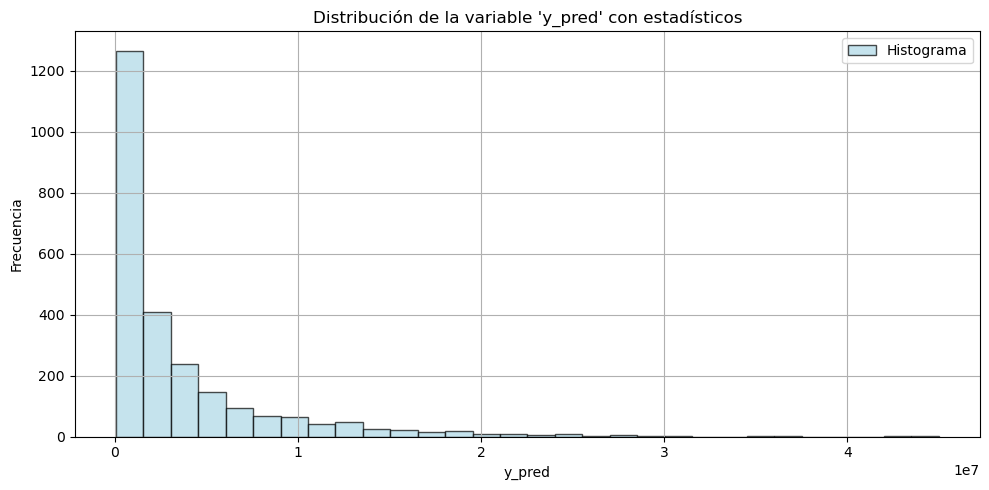

In [123]:
# Estadísticos
media = np.mean(y_pred)
mediana = np.median(y_pred)
std_dev = np.std(y_pred)
# Estadísticos
print(f"Media: {media:.2f}, Mediana: {mediana:.2f}, Desviación estándar: {std_dev:.2f}")

# Histograma con líneas
plt.figure(figsize=(10, 5))
plt.hist(y_pred, bins=30, color='lightblue', edgecolor='black', alpha=0.7, label="Histograma")

# Líneas estadísticas
#plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f"Media: {media:,.0f}")
#plt.axvline(mediana, color='green', linestyle='-.', linewidth=2, label=f"Mediana: {mediana:,.0f}")
#plt.axvline(media + std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media + 1σ")
#plt.axvline(media - std_dev, color='orange', linestyle=':', linewidth=1.5, label=f"Media - 1σ")

# Estética
plt.title("Distribución de la variable 'y_pred' con estadísticos")
plt.xlabel("y_pred")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [124]:
"""Comparación entre la implementación Nuestro modelo y sklearn"""
from sklearn.model_selection import train_test_split


# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Modelo custom
model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Modelo sklearn
reg = PoissonRegressor(alpha=1.0, max_iter=300)
reg.fit(X_train, y_train)
y_pred_train_sklearn = reg.predict(X_train)
y_pred_test_sklearn = reg.predict(X_test)

# Métricas
print("Nuestro PoissonRegression:")
print("Train MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2:", r2_score(y_test, y_pred_test))
print("Coef nuestro:", model.theta)

print("\nsklearn PoissonRegressor:")
print("Train MAE:", mean_absolute_error(y_train, y_pred_train_sklearn))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test_sklearn))
print("Train R2:", r2_score(y_train, y_pred_train_sklearn))
print("Test R2:", r2_score(y_test, y_pred_test_sklearn))
print("Coef sklearn:", np.append(reg.intercept_, reg.coef_))

Convergencia alcanzada en la iteración 1825
Nuestro PoissonRegression:
Train MAE: 1199.3152636024233
Test MAE: 1245.2162777532772
Train R2: 0.999999874996192
Test R2: 0.9999998748388393
Coef nuestro: [14.16992708  0.11307576 -0.11307576  0.58488904  1.29178212]

sklearn PoissonRegressor:
Train MAE: 1199.2973145375097
Test MAE: 1245.1113008871812
Train R2: 0.9999998750270758
Test R2: 0.9999998748282389
Coef sklearn: [14.16992878  0.11307575 -0.11307575  0.58488871  1.29178069]
